In [1276]:
import pandas as pd

df =pd.read_parquet("data.parquet")


## Conversion des types

In [1277]:
df_original = df.copy()

In [1278]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [1279]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [1280]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [1281]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [1282]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

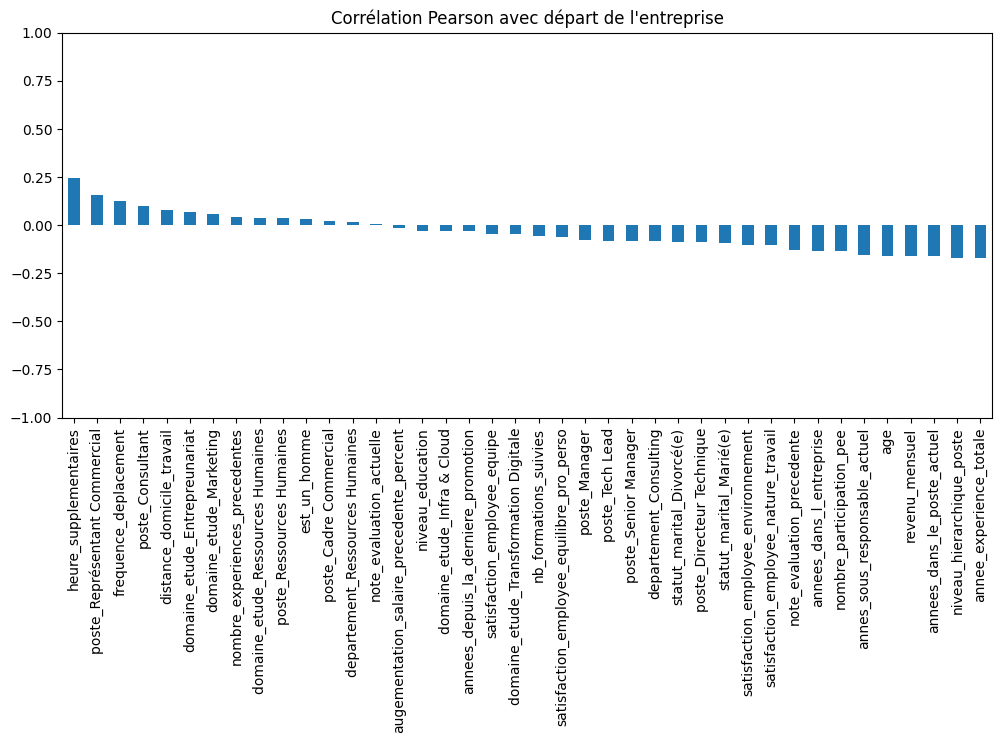

In [1283]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [1284]:
from sklearn.model_selection import train_test_split

def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# Entrainement

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)


Points importants:
* Nous privilégions le recall pour minimiser les faux-négatifs par rapport aux faux-positifs car nous estimons qu'il est important de ne pas louper un salarié démissionaire

In [1285]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# calcule le taux de distribution pour chaque fold (True/False)
# permet de vérifier si la distribution n'est pas trop déséquilibré (<10%)
def get_split_distribution(cv, X, y):
    dist = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        dist.append([
            ((y_train_fold == True).sum() / len(y_train_fold)).round(3), # train_pos
            ((y_train_fold == False).sum() / len(y_train_fold)).round(3), # train_neg
            ((y_test_fold == True).sum() / len(y_test_fold)).round(3), # test_pos
            ((y_test_fold == False).sum() / len(y_test_fold)).round(3), # test_neg
        ])

    return dist

def cross_validate(model_name: str, params):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # validation croisée stratifié
    # pour comparaison des recall's avec le modele entrainé
    #
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # calcule le taux de distribution pour chaque fold (True/False)
    # permet de vérifier si la distribution n'est pas trop déséquilibré (<10% de True)
    dist = get_split_distribution(cv, X_train, y_train)

    return {
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "recall_cross_dist" : dist
            }


def entrainement_model(model_name: str, params, threshold, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # Entraînement
    #
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [1286]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
import pandas as pd

def print_split_distribution(*args) -> None:

    print("Validation croisée stratifié 'recall'")
    print("   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.")
    print("   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.")

    print()

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                for r in results_list:
                    print(r["model"])
                    results = pd.DataFrame(results_list, columns=["recall", "recall_cross_mean", "recall_cross"])
                    display(results.T)
                    display(pd.DataFrame(r["recall_cross_dist"]))

def print_results(*args) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("AUC")
    print("   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                results = pd.DataFrame(results_list, columns=["model", "accuracy", "precision", "recall", "f1", "r2", "auc"])
                display(results)


def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(3, len(results_list), figsize=(15, 8))

        for results in results_list:
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [1287]:
from IPython.display import display, Markdown

class BaseTrain:
    pass_list = []
    pass_names = []
    pass_num = 0 # numero de passe d'entrainement (pour affichage)

    # Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
    threshold = {
        "LogisticRegression" : 0.5,
        "DummyClassifier" : 0.5,
        "XGBoost" : 0.5,
        "RandomForestClassifier" : 0.5,
        "DecisionTreeClassifier" : 0.5,
    }

    #
    # paramètres de chaque modèle
    #
    Params = {
        # un modèle linéaire
        "LogisticRegression" : {
            
        },

        # un modèle dummy
        "DummyClassifier" : {
            "strategy":"stratified",
            "random_state": 42
        },

        # un modèle non-linéaire
        "XGBoost" : {
            "n_estimators": 200,
            "max_depth": 4,
            "eval_metric": "logloss" # pénaliser fortement les FN, favoriser le rappel
        },

        #
        # autres paramètres de modèles (pour test)
        #

        "RandomForestClassifier" : {
            "n_estimators": 200,
            "random_state": 42
        },

        "DecisionTreeClassifier" : {
            "max_depth": 4,
            "random_state": 42
        }
    }

    def __init__(self, desc):
        self.name = self.__class__.__name__
        self.desc = desc
        BaseTrain.pass_names.append(self.name)
        
    def before(self):
        return None

    def after(self):
        return None

    def train_and_evaluate(self):
        
        self.before()

        self.results_list = []
        self.results_list.append(entrainement_model("DummyClassifier", BaseTrain.Params["DummyClassifier"], BaseTrain.threshold["DummyClassifier"], True))
        self.results_list.append(entrainement_model("LogisticRegression", BaseTrain.Params["LogisticRegression"], BaseTrain.threshold["LogisticRegression"], True))
        self.results_list.append(entrainement_model("XGBoost", BaseTrain.Params["XGBoost"], BaseTrain.threshold["XGBoost"], True))
        BaseTrain.pass_list.append(self.results_list)

        self.train_results_list = []
        self.train_results_list.append(entrainement_model("DummyClassifier", BaseTrain.Params["DummyClassifier"], BaseTrain.threshold["DummyClassifier"], False))
        self.train_results_list.append(entrainement_model("LogisticRegression", BaseTrain.Params["LogisticRegression"], BaseTrain.threshold["LogisticRegression"], False))
        self.train_results_list.append(entrainement_model("XGBoost", BaseTrain.Params["XGBoost"], BaseTrain.threshold["XGBoost"], False))

        BaseTrain.pass_num = BaseTrain.pass_num+1
        
        self.after()
        
    def print(self):
        display(Markdown(f"""# PASSE N°{BaseTrain.pass_num}\n## {self.name}\n\n**{self.desc}**"""))

        print_results(self.results_list, self.train_results_list)
        display_results(self.results_list, self.train_results_list)

In [1288]:
# séparation train/test

separation_train_test()


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°1
## InitialTrain

**Premier entrainement**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.728,0.098,0.128,0.111,NaN,0.474
1,LogisticRegression,0.881,0.577,0.385,0.462,NaN,0.791
2,XGBoost,0.874,0.545,0.308,0.393,NaN,0.784


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.709,0.150,0.157,0.153,NaN,0.489
1,LogisticRegression,0.888,0.762,0.485,0.593,NaN,0.882
2,XGBoost,1.000,1.000,1.000,1.000,NaN,1.000


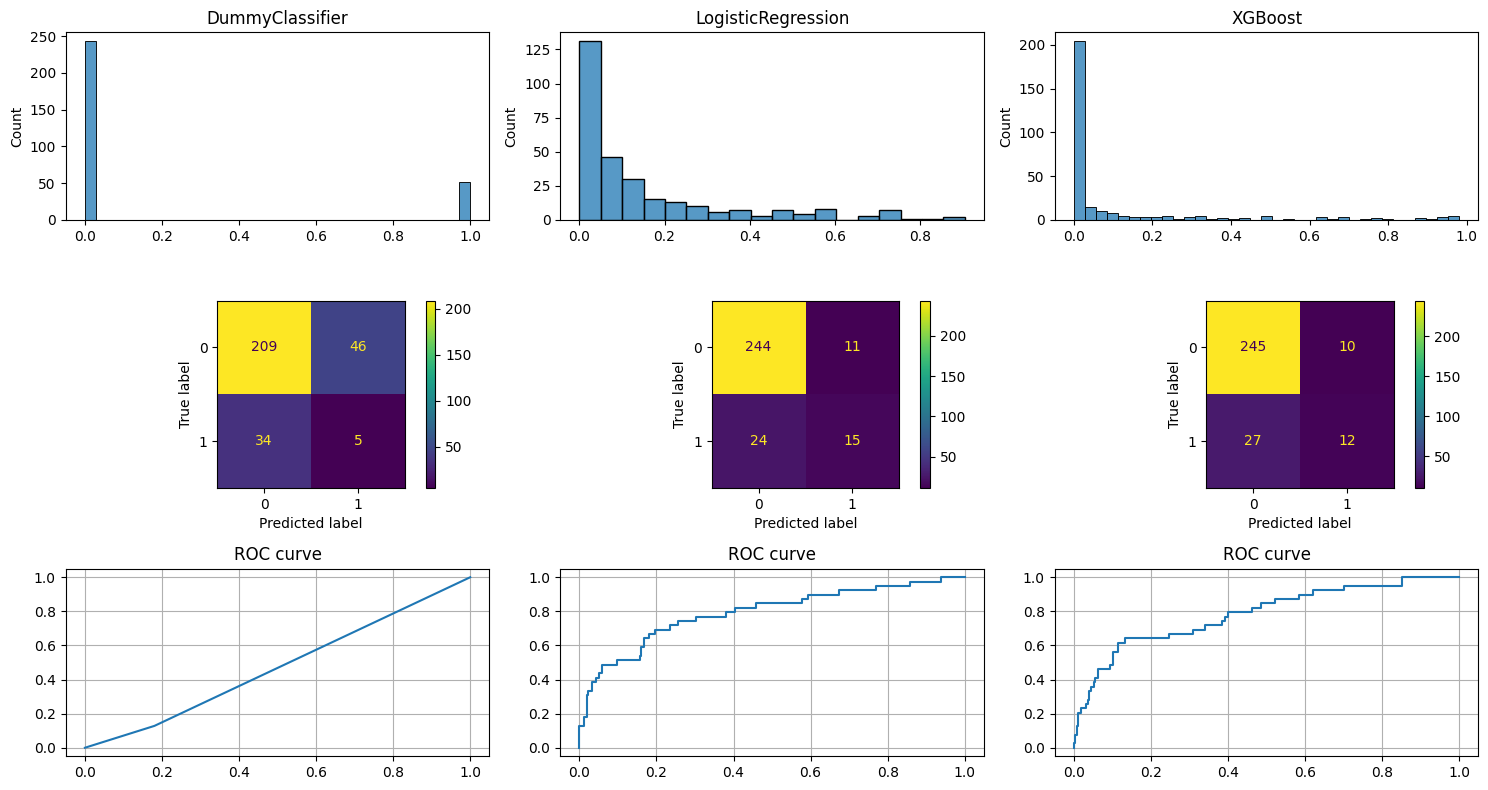

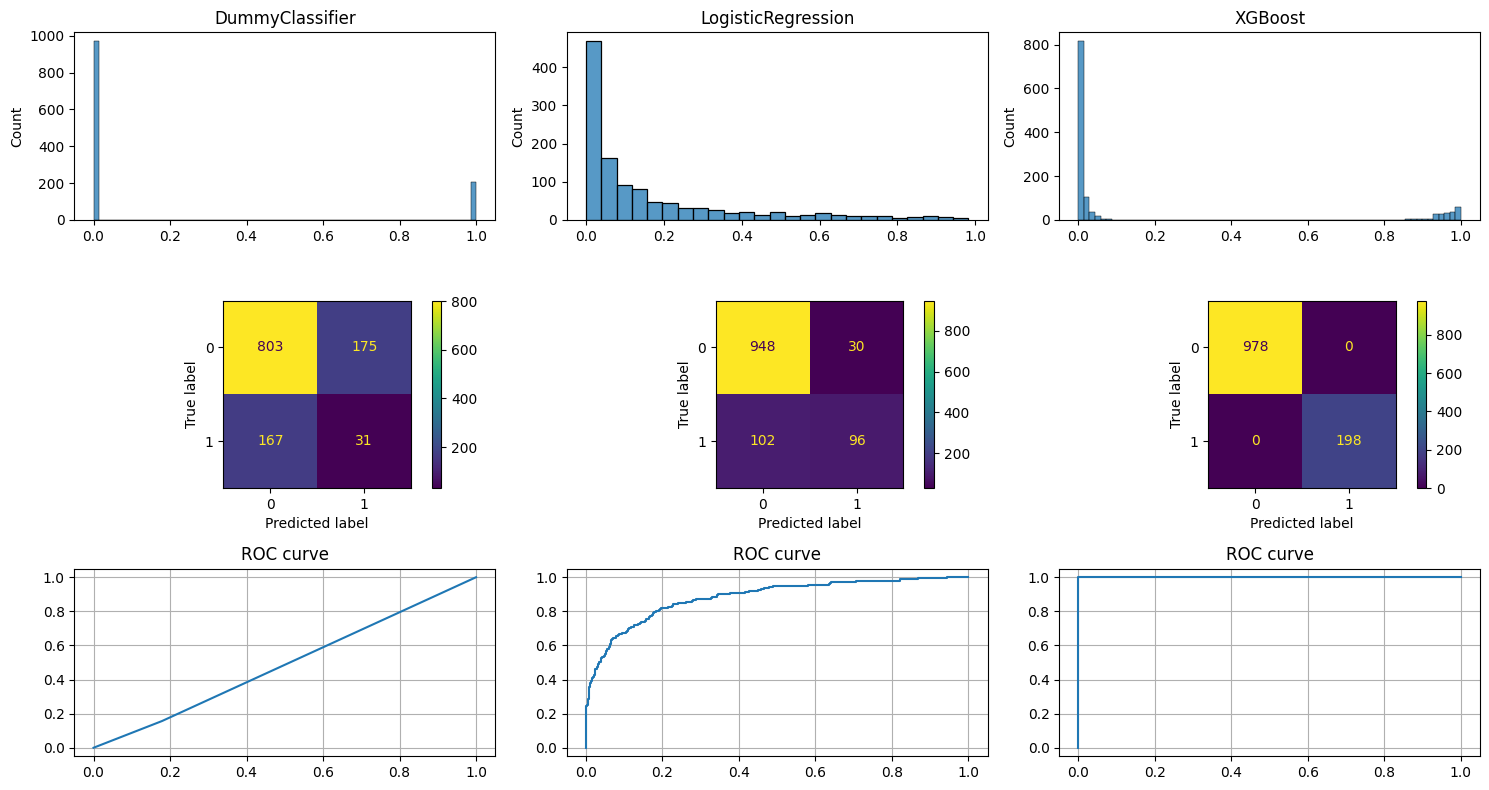

In [1289]:
class InitialTrain(BaseTrain):
    def before(self):
        return None

    def after(self):
        return None

passInst = InitialTrain("Premier entrainement")
passInst.train_and_evaluate()
passInst.print()

## validation croisée

Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.
   Si < 10% de positifs le jeu est mal proportionné
   
StratifiedKFold équilibre les proportions de True/False, si OK, le jeu est bien distribué.

Si non, vérifier:
* modèle XGBoost
* seuil de décision
* qualité des variables explicatives
* surapprentissage ?

In [1290]:
if BaseTrain.threshold["XGBoost"] != 0.5:
    raise RuntimeError("Pour comparer le recall de cross_validate avec le model, ce dernier doit utiliser un seuil de 0.5")

results = cross_validate("XGBoost", BaseTrain.Params["XGBoost"]) # seuil implicite = 0.5

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

print_split_distribution([results | result])

Validation croisée stratifié 'recall'
   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.

XGBoost


,0
recall,0.308
recall_cross_mean,0.389
recall_cross,"[0.275, 0.385, 0.41, 0.475, 0.4]"


,0,1,2,3
0,0.168,0.832,0.169,0.831
1,0.169,0.831,0.166,0.834
2,0.169,0.831,0.166,0.834
3,0.168,0.832,0.170,0.830
4,0.168,0.832,0.170,0.830


classe positive (True) : ~17 %
classe négative (False) : ~83 %

Distribution plutot saine:
* pas de fold sans positifs
* pas de déséquilibre extrême
* stratification globalement correcte

# Feature enginering

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


# PASSE N°2
## FeatureEngineringPass

**Crée de nouvelles features**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.728,0.098,0.128,0.111,NaN,0.474
1,LogisticRegression,0.871,0.522,0.308,0.387,NaN,0.798
2,XGBoost,0.871,0.522,0.308,0.387,NaN,0.779


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.709,0.150,0.157,0.153,NaN,0.489
1,LogisticRegression,0.896,0.802,0.510,0.623,NaN,0.878
2,XGBoost,1.000,1.000,1.000,1.000,NaN,1.000


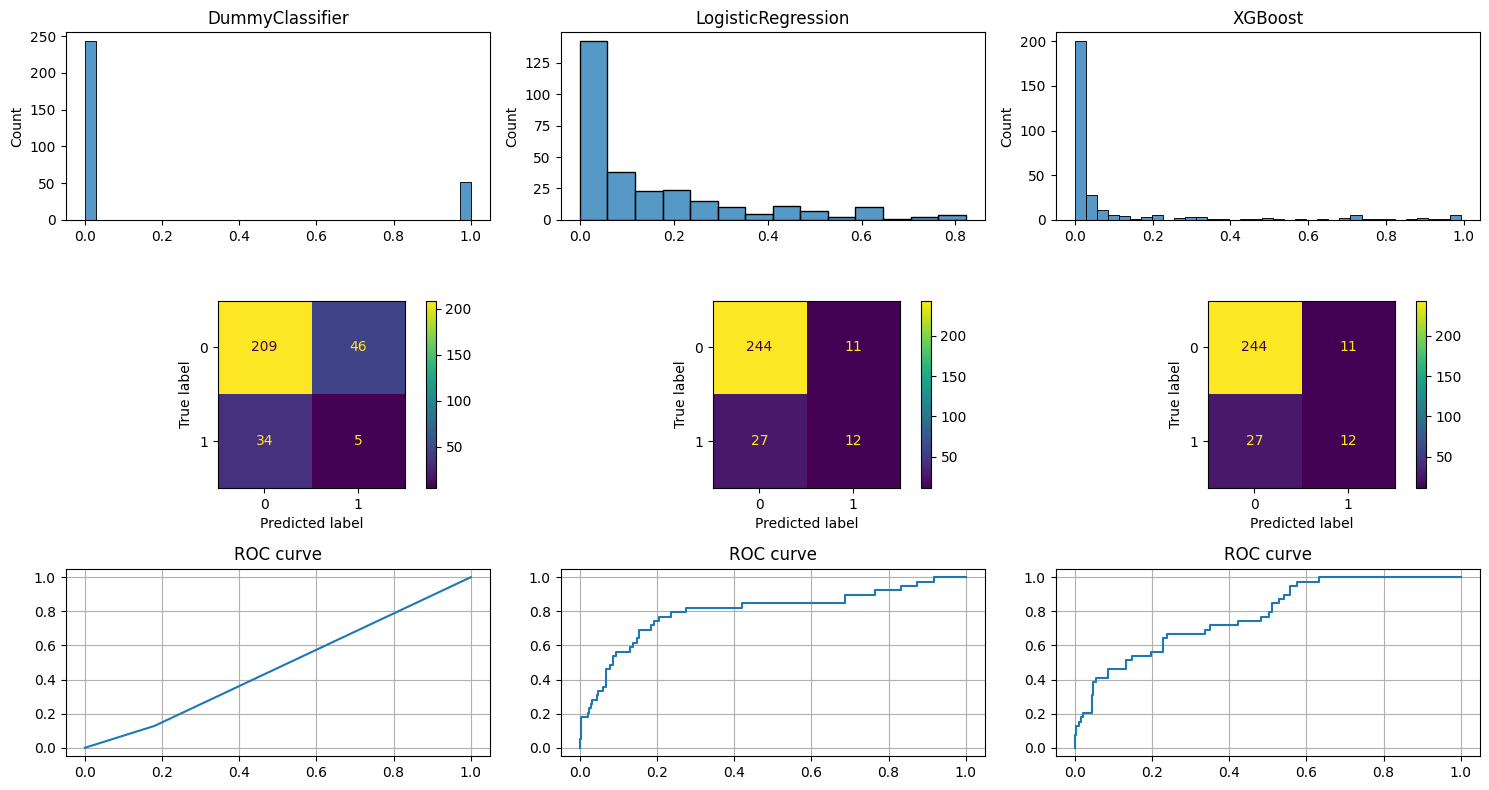

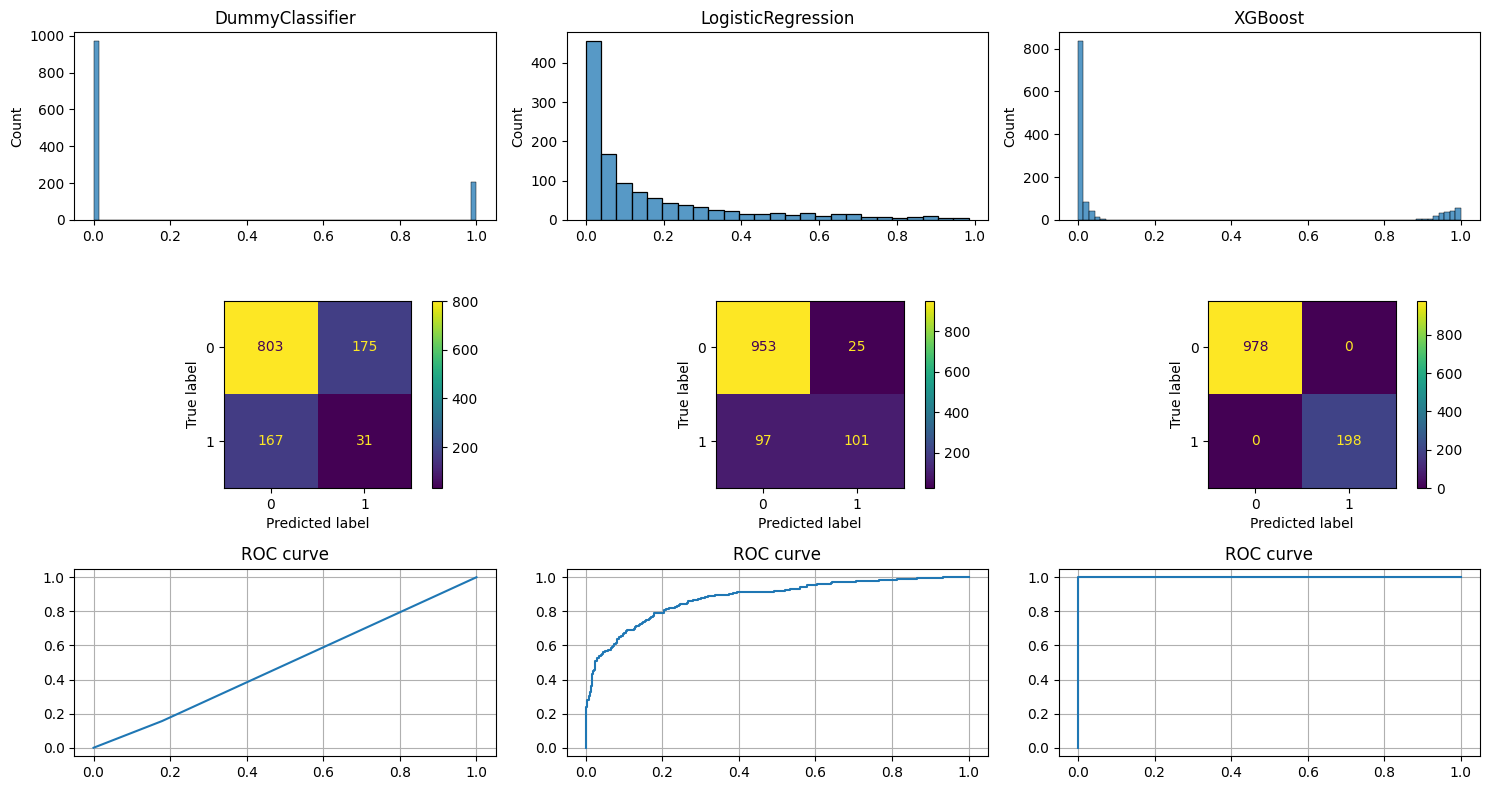

In [1291]:
class FeatureEngineringPass(BaseTrain):
    def before(self):
        global df
        
        # mesure si la personne reste longtemps dans le même poste
        df["anciennete_relative"] = df["annees_dans_l_entreprise"] / (df["annee_experience_totale"] + 1)

        # mesure si la personne reste longtemps dans le même poste
        df["stagnation"] = df["annees_dans_l_entreprise"] - df["annees_dans_le_poste_actuel"]

        # promotion attendue
        df["retard_promotion"] = df["annees_depuis_la_derniere_promotion"] / (df["annees_dans_l_entreprise"]+1)

        # expérience externe vs interne
        df["progression"] = df["annee_experience_totale"] - df["annees_dans_l_entreprise"]

        # détecte sous-rémunération potentielle
        df["salaire_par_annee"] = df["revenu_mensuel"] / (df["annees_dans_l_entreprise"] + 1)

        # Sous-positionnement hiérarchique
        #df["niveau_par_annee"] = df["niveau_hierarchique_poste"] / (df["annees_dans_l_entreprise"] + 1)
        
        df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

        df["insatisfaction_globale"] = (
            df["satisfaction_employee_nature_travail"] +
            df["satisfaction_employee_equipe"] +
            df["satisfaction_employee_equilibre_pro_perso"]
        )

        df.drop(columns=[
            #"heure_supplementaires",
            #"nombre_participation_pee",
            #"nb_formations_suivies",
            #"distance_domicile_travail",
            "niveau_education",
            #"frequence_deplacement",
            #"annees_depuis_la_derniere_promotion",
            "annes_sous_responsable_actuel",
            #"age",
            #"revenu_mensuel",
            #"nombre_experiences_precedentes",
            #"annee_experience_totale",
            #"annees_dans_l_entreprise",
            #"annees_dans_le_poste_actuel",
            #"note_evaluation_precedente",
            #"satisfaction_employee_environnement",
            #"satisfaction_employee_nature_travail",
            #"satisfaction_employee_equipe",
            #"satisfaction_employee_equilibre_pro_perso",
            "note_evaluation_actuelle",
            #"heure_supplementaires",
            #"augementation_salaire_precedente_percent",
            #"est_un_homme",
            #"domaine_etude_Entrepreunariat",
            #"domaine_etude_Infra & Cloud",
            #"domaine_etude_Marketing",
            #"domaine_etude_Ressources Humaines",
            #"domaine_etude_Transformation Digitale",
            #"statut_marital_Divorcé(e)",
            "statut_marital_Marié(e)",
            #"departement_Consulting",
            #"departement_Ressources Humaines",
            #"poste_Cadre Commercial",
            #"poste_Consultant",
            #"poste_Directeur Technique",
            #"poste_Manager",
            #"poste_Représentant Commercial",
            #"poste_Ressources Humaines",
            #"poste_Senior Manager",
            #"poste_Tech Lead",
        ], inplace=True)
        
        # on recréer le jeu de données
        separation_train_test()

passInst = FeatureEngineringPass("Crée de nouvelles features")
passInst.train_and_evaluate()
passInst.print()

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [1292]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [1293]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.831633
1    0.168367
Name: proportion, dtype: float64

In [1294]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.867347
1    0.132653
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie



Dans ce type de situation (ex : démissions rares), XGBoost peut privilégier fortement la classe majoritaire.

Résultat :

prédictions quasi toujours négatives
donc faux négatifs élevés
rappel très faible voire nul sur certains folds

# optimisation des hyperparamètres

237 1233 5.2025316455696204


# PASSE N°3
## ScaleParamsPass

**Gestion du déséquilibre : démission/en place**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.728,0.098,0.128,0.111,NaN,0.474
1,LogisticRegression,0.871,0.522,0.308,0.387,NaN,0.798
2,XGBoost,0.864,0.485,0.410,0.444,NaN,0.758


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.709,0.150,0.157,0.153,NaN,0.489
1,LogisticRegression,0.896,0.802,0.510,0.623,NaN,0.878
2,XGBoost,1.000,1.000,1.000,1.000,NaN,1.000


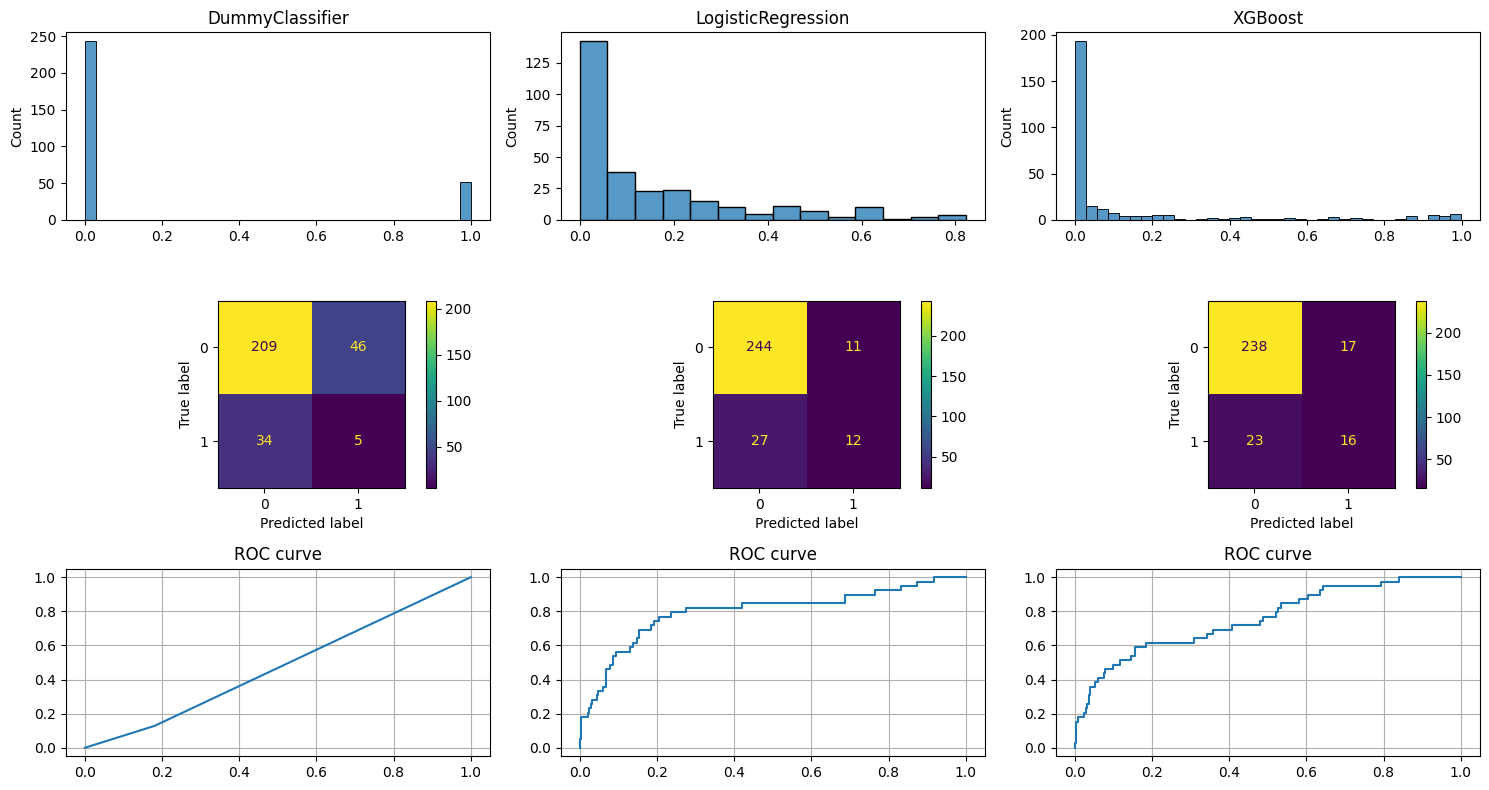

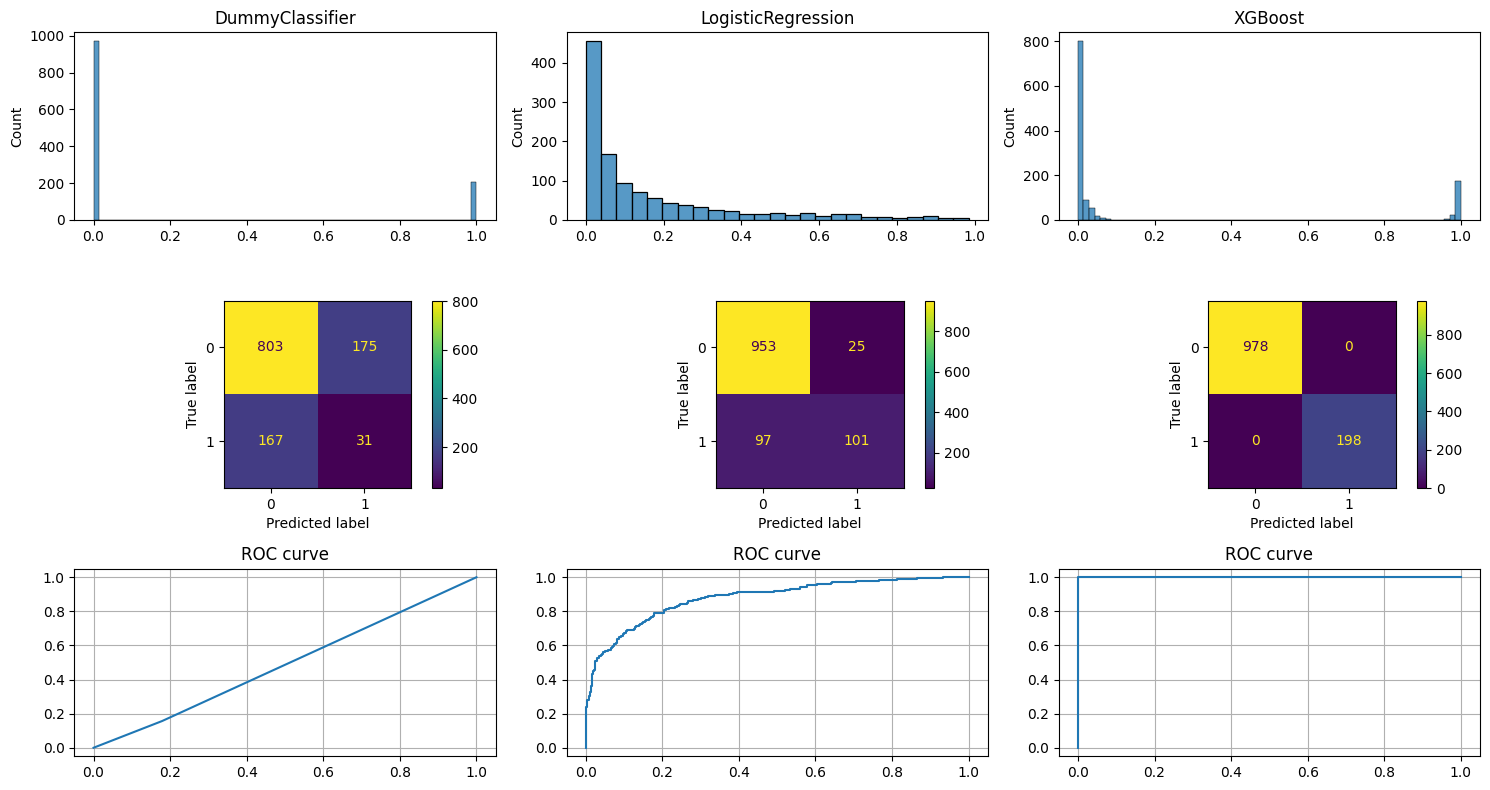

In [1295]:
class ScaleParamsPass(BaseTrain):
    def before(self):
        BaseTrain.Params["RandomForestClassifier"]["class_weight"] = "balanced"

        # equilibre le poids 
        nb_pos = (df["a_quitte_l_entreprise"] == True).sum()
        nb_neg = (df["a_quitte_l_entreprise"] == False).sum()
        BaseTrain.Params["XGBoost"]["scale_pos_weight"] = nb_neg / nb_pos
        print(nb_pos, nb_neg, BaseTrain.Params["XGBoost"]["scale_pos_weight"])

passInst = ScaleParamsPass("Gestion du déséquilibre : démission/en place")
passInst.train_and_evaluate()
passInst.print()

# recherche des hyperparamètres

In [1296]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

run = False # executé 1 fois pour info

if run:

    model = XGBClassifier()

    param_grid = {
        "max_depth": [3, 5],
        "n_estimators": [100, 300],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "reg_lambda": [1, 5],
        "reg_alpha": [0, 1],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 5]
    }

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

In [1297]:
grid.best_score_

np.float64(0.5427236726820401)

In [1298]:
grid.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 300,
 'reg_alpha': 0,
 'reg_lambda': 5,
 'subsample': 0.8}

# PASSE N°4
## HyperParamsPass

**Ajuste les hyper paramètres de XGBoost**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.728,0.098,0.128,0.111,NaN,0.474
1,LogisticRegression,0.871,0.522,0.308,0.387,NaN,0.798
2,XGBoost,0.850,0.442,0.487,0.463,NaN,0.776


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.709,0.150,0.157,0.153,NaN,0.489
1,LogisticRegression,0.896,0.802,0.510,0.623,NaN,0.878
2,XGBoost,0.991,0.947,1.000,0.973,NaN,1.000


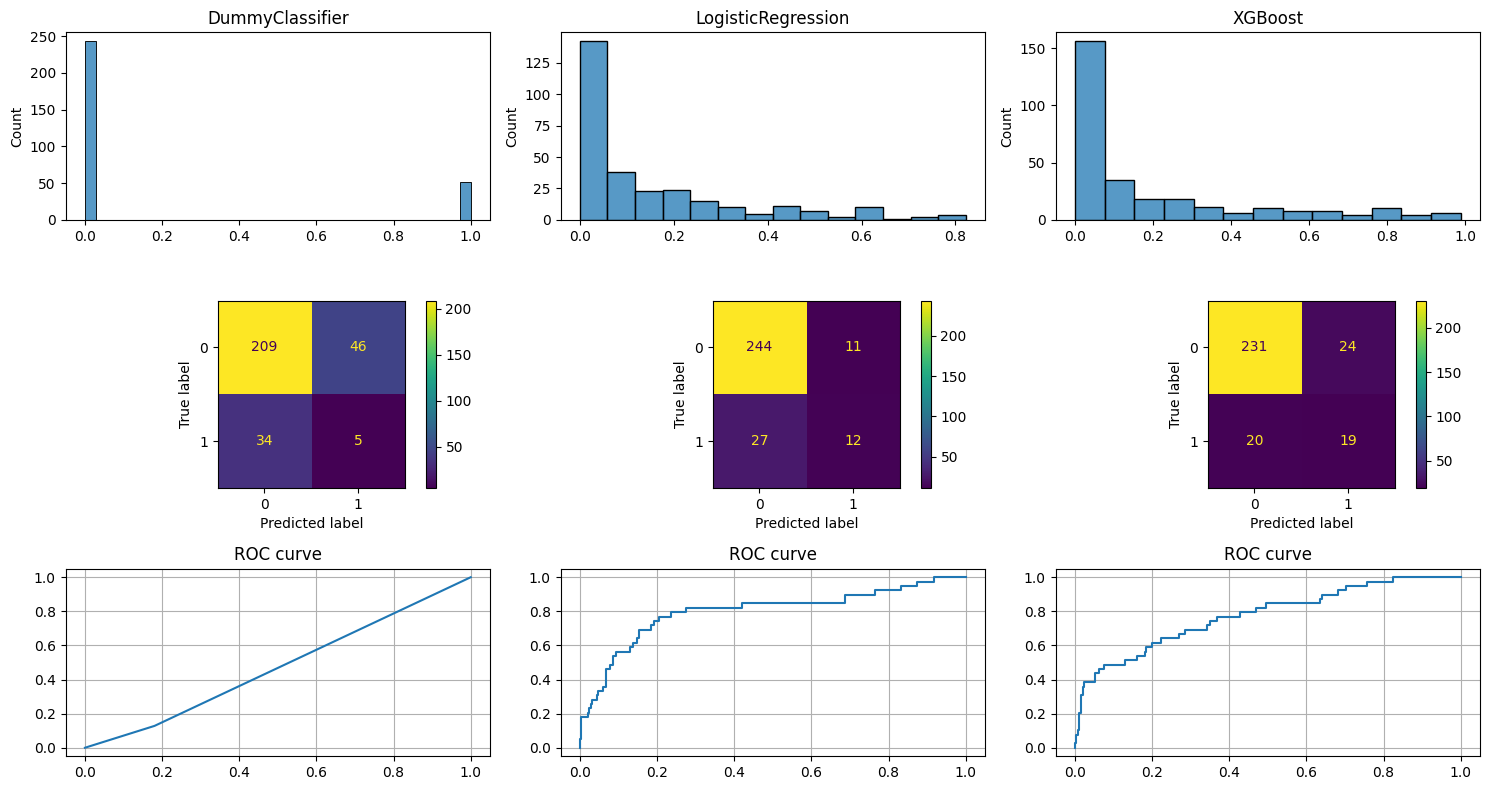

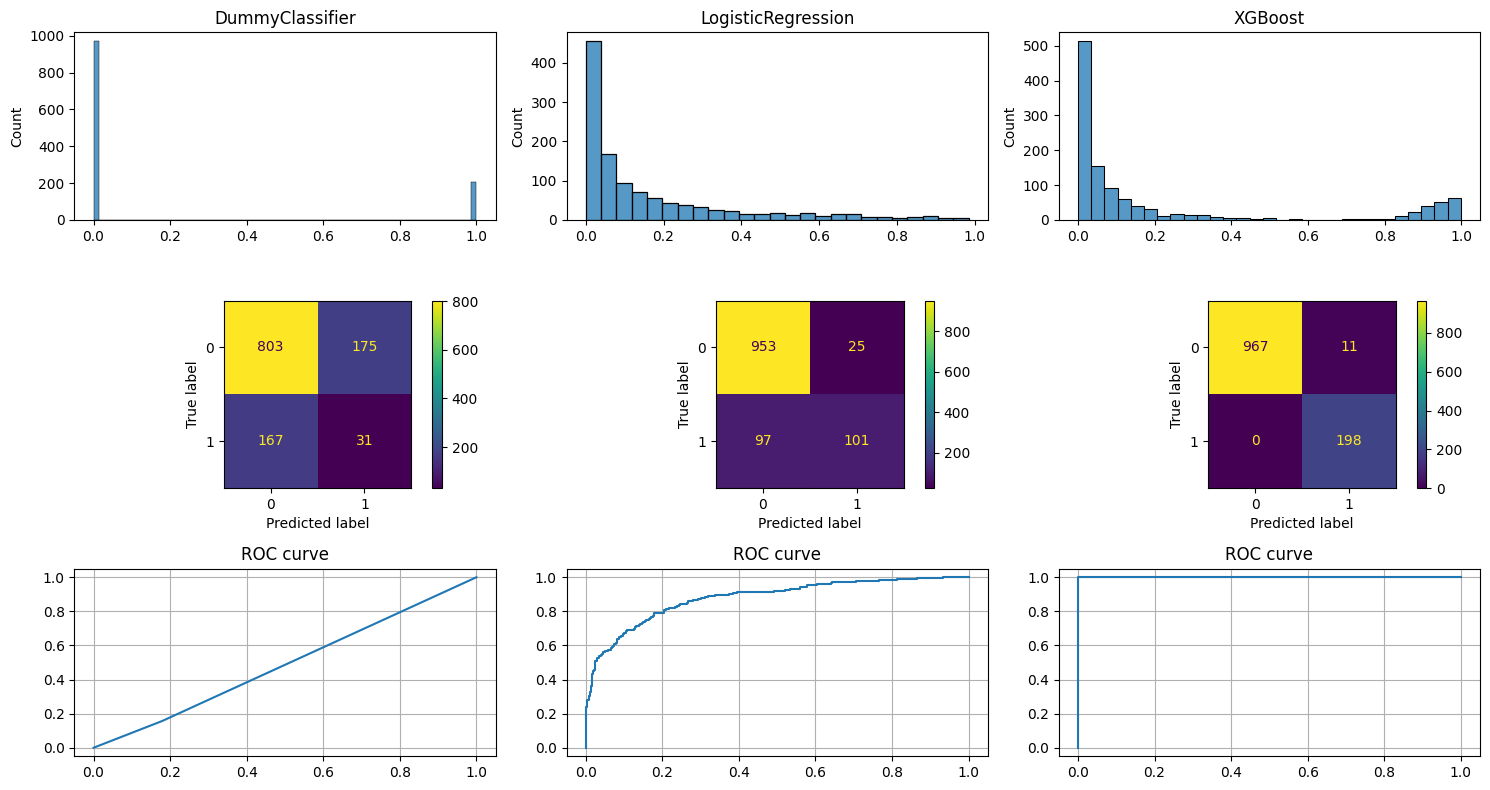

In [1299]:
class HyperParamsPass(BaseTrain):
    def before(self):
        BaseTrain.Params["XGBoost"]["max_depth"] = 3
        BaseTrain.Params["XGBoost"]["n_estimators"] = 300
        #BaseTrain.Params["XGBoost"]["reg_lambda"] = 5
        #BaseTrain.Params["XGBoost"]["reg_alpha"] = 0
        BaseTrain.Params["XGBoost"]["subsample"] = 0.8
        #BaseTrain.Params["XGBoost"]["colsample_bytree"] = 1.0
        #BaseTrain.Params["XGBoost"]["min_child_weight"] = 5
        BaseTrain.Params["XGBoost"]["learning_rate"] = 0.1

passInst = HyperParamsPass("Ajuste les hyper paramètres de XGBoost")
passInst.train_and_evaluate()
passInst.print()

# recherche du meilleur seuil (XGBoost)

DummyClassifier Best threshold: 0.1
DummyClassifier Best F1: 0.1111111111111111
LogisticRegression Best threshold: 0.2
LogisticRegression Best F1: 0.49586776859504134
XGBoost Best threshold: 0.7000000000000001
XGBoost Best F1: 0.47619047619047616


# PASSE N°5
## ThresholdPass

**Ajuste le seuil de décision en fonction du meilleur F1-score**

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.728,0.098,0.128,0.111,NaN,0.474
1,LogisticRegression,0.793,0.366,0.769,0.496,NaN,0.798
2,XGBoost,0.888,0.625,0.385,0.476,NaN,0.776


,model,accuracy,precision,recall,f1,r2,auc
0,DummyClassifier,0.709,0.150,0.157,0.153,NaN,0.489
1,LogisticRegression,0.815,0.469,0.773,0.584,NaN,0.878
2,XGBoost,0.997,0.995,0.990,0.992,NaN,1.000


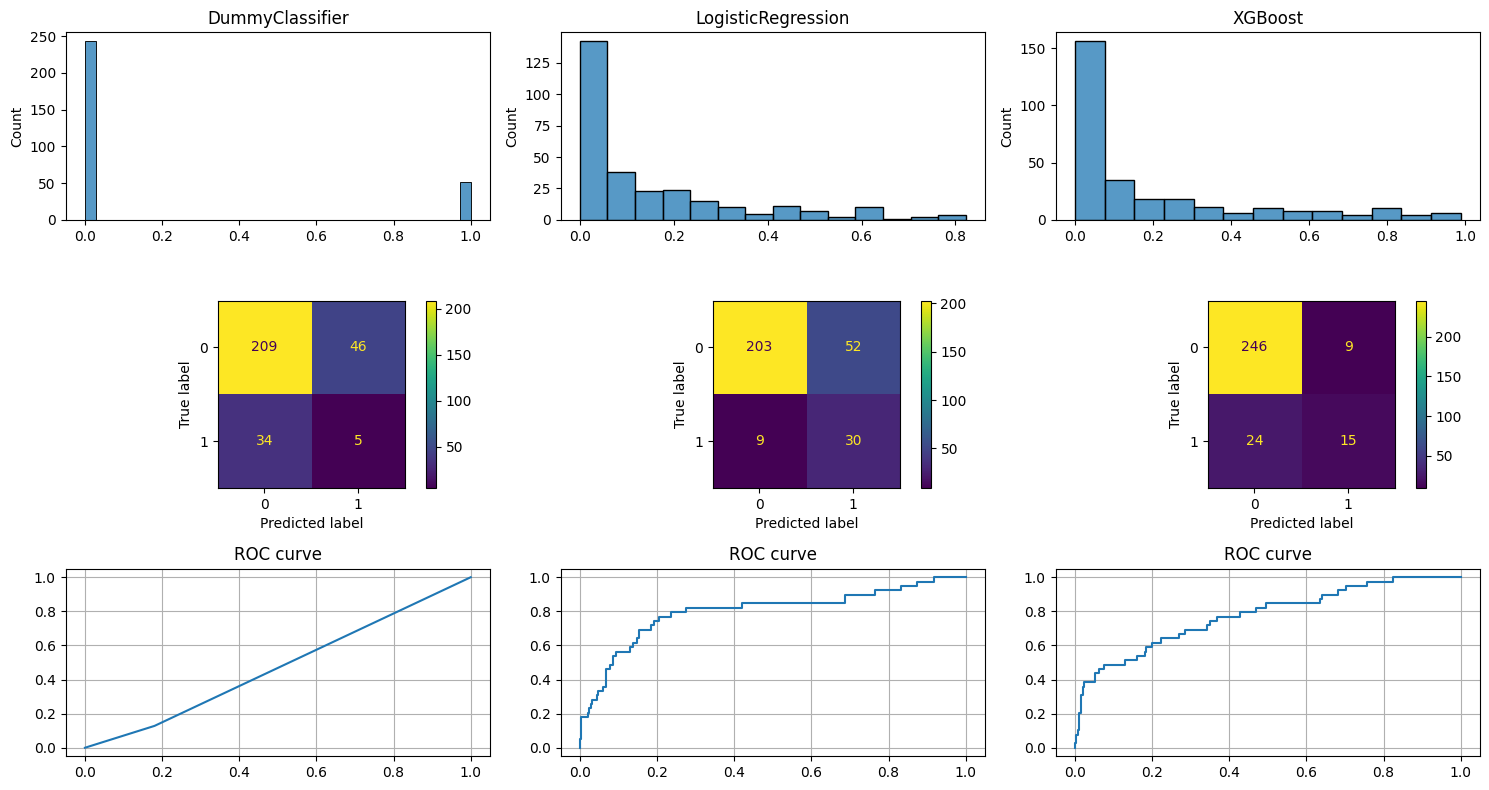

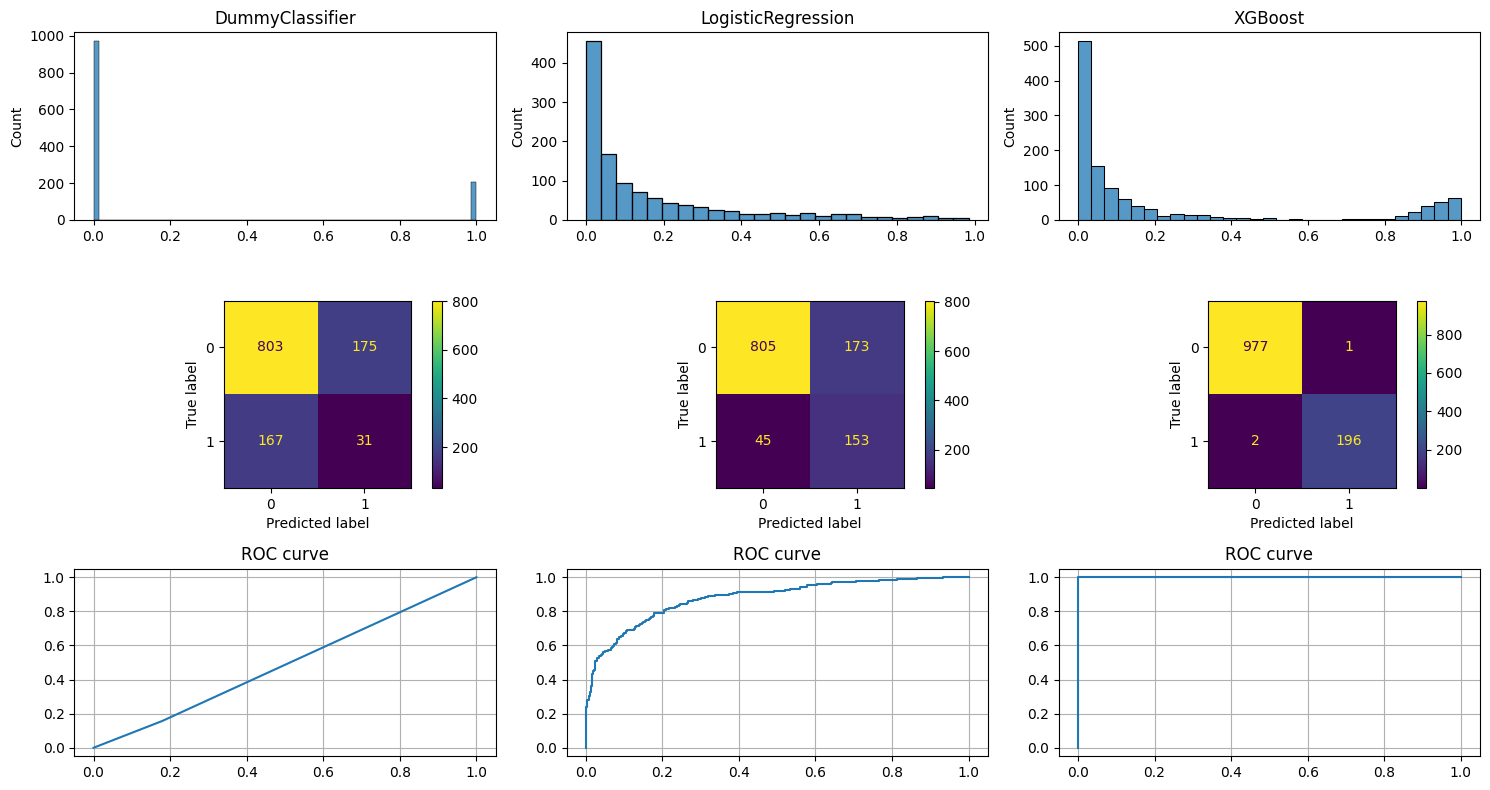

In [1300]:
class ThresholdPass(BaseTrain):

    def before(self):
                
        # noms des modèles (pris sur la première passe)
        models = [r["model"] for r in BaseTrain.pass_list[0]]

        for model in models:
            best_t, best_f1 = 0, 0

            for t in range(1, 9, 1):
                threshold = 0.1 * t
                results = entrainement_model(model, BaseTrain.Params[model], threshold, True)

                f1 = results["f1"]
                    
                if f1 > best_f1:
                    best_f1 = f1
                    best_t = threshold

            print(model, "Best threshold:", best_t)

            print(model, "Best F1:", best_f1)

            BaseTrain.threshold[model] = best_t
        

passInst = ThresholdPass("Ajuste le seuil de décision en fonction du meilleur F1-score")
passInst.train_and_evaluate()
passInst.print()

In [1301]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,frequence_deplacement,int64
5,annees_depuis_la_derniere_promotion,int64
6,age,int64
7,revenu_mensuel,int64
8,nombre_experiences_precedentes,int64
9,annee_experience_totale,int64


# Affiche un graphique de l'évolution du F1-score

In [1302]:
display(BaseTrain.Params["XGBoost"])

{'n_estimators': 300,
 'max_depth': 3,
 'eval_metric': 'logloss',
 'scale_pos_weight': np.float64(5.2025316455696204),
 'subsample': 0.8,
 'learning_rate': 0.1}

DummyClassifier
[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111]
LogisticRegression
[0.46153846 0.38709677 0.38709677 0.38709677 0.49586777]
XGBoost
[0.39344262 0.38709677 0.44444444 0.46341463 0.47619048]


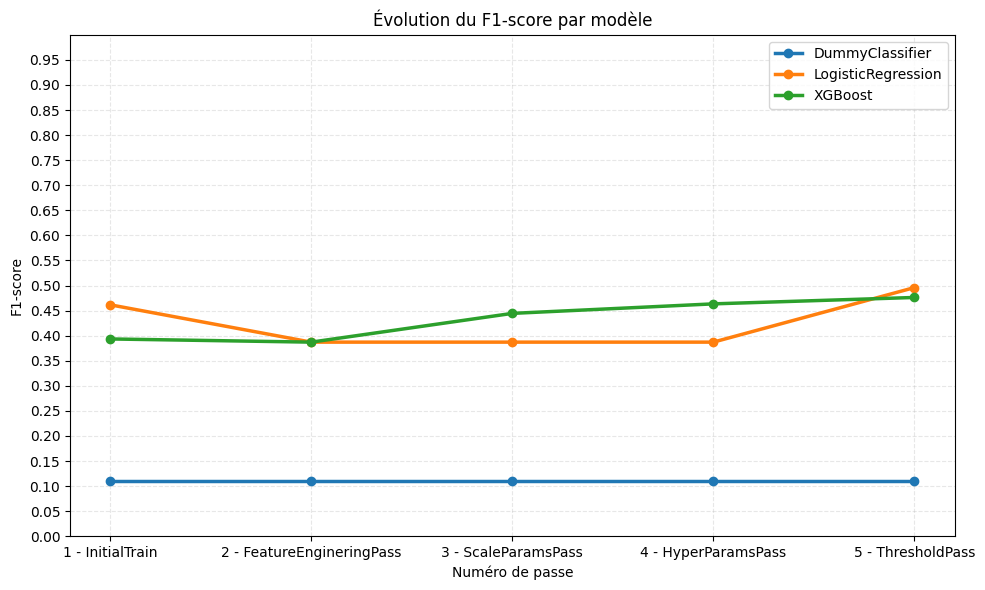

In [1303]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in BaseTrain.pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(BaseTrain.pass_list), len(models)))

j = 0
for results_list in BaseTrain.pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(BaseTrain.pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    print(models[i])
    print(f1_scores)
    
    i += 1


ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


labels_avec_numero = [f"{i+1} - {label}" for i, label in enumerate(BaseTrain.pass_names)]
plt.xticks(x, labels_avec_numero)
plt.yticks(np.arange(0, 1, 0.05))
plt.tight_layout()
plt.show()

# Comparaison des départs réel et prédit en fonction du poste
Permet de confirmer si l'analyse exploratoire dit juste

In [1304]:
df_original.groupby("poste")["a_quitte_l_entreprise"] \
  .mean() \
  .sort_values(ascending=False)

poste
Représentant Commercial    0.397590
Consultant                 0.239382
Ressources Humaines        0.230769
Cadre Commercial           0.174847
Assistant de Direction     0.160959
Tech Lead                  0.068966
Manager                    0.068702
Senior Manager             0.049020
Directeur Technique        0.025000
Name: a_quitte_l_entreprise, dtype: float64

In [1305]:
df_pred = X_test.copy()

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

df_pred["poste"] = df_original.loc[X_test.index, "poste"]

df_pred["proba_depart"] = result["y_proba"]
df_pred["depart_reel"] = result["y"]

df_pred.groupby("poste")["proba_depart"] \
       .mean() \
       .sort_values(ascending=False)

poste
Représentant Commercial    0.379268
Ressources Humaines        0.336987
Consultant                 0.267639
Cadre Commercial           0.246362
Assistant de Direction     0.157765
Tech Lead                  0.106902
Manager                    0.104447
Senior Manager             0.092002
Directeur Technique        0.053973
Name: proba_depart, dtype: float32

# Export

In [1306]:
df.to_parquet("model.parquet")

# visualisation des features importances globales

In [1307]:
import shap

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

# calcul des SHAP values
explainer = shap.TreeExplainer(result["clf"])

shap_values = explainer.shap_values(X_train)

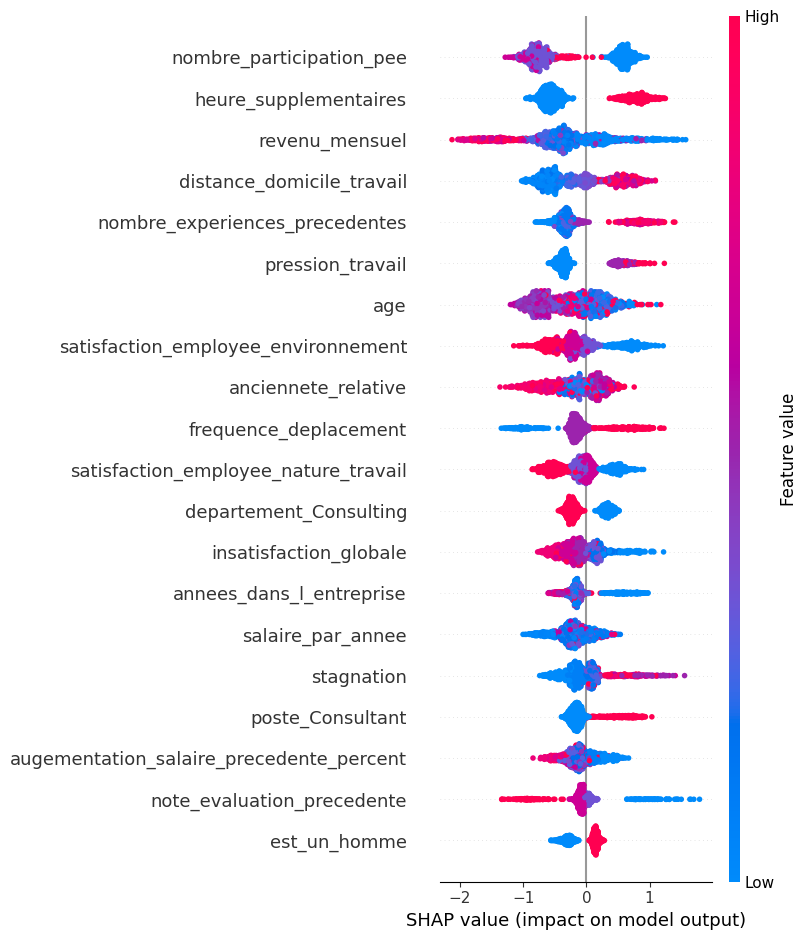

In [1308]:
shap.summary_plot(shap_values, X_train)

Ce graphique répond à la question suivante:
    >> quels facteurs poussent un employé à partir ou rester, et dans quel sens ?

* Les heures supplémentaires (bool) sont parfaitement séparées, elle pèse beaucoup dans la prédiction de quitter l'entreprise => se confirme avec l'exploration des données
* Les revenu pèses aussi beaucoup, les hauts revenus ont bien plus tendance à rester que l'inverse => se confirme avec l'exploration des données 
* Le nombre de participations est également assez tranché, tous les départs ont eu peu de participations =>  se confirme avec l'exploration des données 
* Globalement la satisfaction joue un role
* les déplacements sont aussi tranché malgré une base mixte